In [153]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib import cm

from src import loader, plotter
from datetime import timedelta

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.fdu import functional_dynamic_update
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 48
method = 'fusion'
resource = 'wind'
aggregation = 'zone'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [724]:
# exp_description="unbiased-025-C0"
# _init = {6: 4, 12: 3, 18: 2}

# exp_description="unbiased-025-C1"
# _init = {6: 3, 12: 3, 18: 1}

exp_description="unbiased-025-C2"
_init = {6: 1, 12: 1, 18: 1}

# exp_description="biased-025-C1"
# _init = {6: 1, 12: 4, 18: 1}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation=VALIDATION,
)
hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)

# stats_, funcs_ = loader.get_zone_stats(
#     _init, 
#     resource, 
#     method, 
#     aggregation, 
#     exp_description, 
#     T, 
#     VALIDATION, 
# )
# print(stats_)
# print(funcs_)
dates_ = np.random.default_rng(1234).permutation(np.arange(360))[180:]

time                     6            12           18
clique_order       2.000000     2.000000     2.000000
p_fusion           1.000000     1.000000     1.000000
forget_rate_f      0.500000     0.500000     0.500000
forget_rate_e      1.000000     1.000000     1.000000
lookahead_rate    24.000000    24.000000    24.000000
tau                0.001000     0.001000     0.001000
kappa            200.000000   200.000000   200.000000
rho_e              0.083124     0.097226     0.427788
rho_d              0.155646     0.244294     0.000082
nu                 2.000000     2.000000     2.000000
sigma              0.209312     0.256376     0.595511
length_scale_f  1000.000000  1000.000000  1000.000000
length_scale_e    83.123794    97.225977   427.788048
length_scale_d   155.646204   244.293782     0.081593


In [725]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION)
print(latex)

df_fmt, latex = loader.envelope_scores(
    envelope_, 
    alphas = [0.1, 0.2]
)
print(latex)

\begin{table}
\caption{Forecast error metrics by lead time and distance method.}
\label{tab:error_metrics}
\begin{tabular}{clccc}
\toprule
 &  & RMSE & MAE & MBE \\
Forecast Update Time $\tau$ & Estimator &  &  &  \\
\midrule
\multirow[c]{3}{*}{6} & nan & 0.1964 & 0.1601 & 0.0143 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1810 & 0.1505 & 0.0047 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1240 & 0.1029 & 0.0050 \\
\multirow[c]{3}{*}{12} & nan & 0.1978 & 0.1609 & 0.0100 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1803 & 0.1508 & 0.0038 \\
 & $\hat{\mu}_{focal}(s)$ & 0.1220 & 0.1008 & 0.0032 \\
\multirow[c]{3}{*}{18} & nan & 0.2011 & 0.1621 & 0.0076 \\
 & $\hat{\mu}_{deep}(s)$ & 0.1292 & 0.1058 & 0.0145 \\
 & $\hat{\mu}_{focal}(s)$ & 0.0942 & 0.0767 & 0.0048 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Forecast error metrics by update time and estimator.}
\label{tab:error_metrics}
\begin{tabular}{clccccccccccccccc}
\toprule
 &   & \multicolumn{5}{c}{FIS} & \multicolumn{5}{c}{FCS} & \multicolumn{5}{c}{S

In [736]:
zone = 1

(F_tr_, F_ts_, 
 E_tr_, E_ts_, 
 d_tr_, d_ts_, 
 t_tr_, t_ts_, 
 X_tr_, X_ts_, 
 dt_, regions_, region
) = loader.processed_zone_dataset(
    path_to_data = DATA / "gridstatus/processed_ERCOT_wind_data_v4.pkl",
    zone = zone,
    N_test_samples = 360,
    unbiased = True
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(d_tr_.shape, d_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(dt_.shape)
print(region)
print(regions_)

(3290, 24, 72) (360, 24, 72)
(3290, 24, 48) (360, 24, 48)
(3290,) (360,)
(3290, 24, 72) (360, 24, 72)
(3290, 2) (360, 2)
(72,)
North
['Coastal', 'North', 'Panhandle', 'South', 'West']


In [737]:
print(np.unique(X_tr_[:, 0]))
print(np.unique(X_tr_[:, 1]))
print(X_ts_[day])

[0. 1. 2. 3. 4.]
[0. 1. 2.]
[1. 0.]


North Aug 4 1am
(3290, 72) (3290, 72)
(24,) (48,) (48,) (72,)
0.0057949439861144855 2
North Aug 4 1am
[0 1 2] [108  33  59]
[0. 1. 2.]
wind-North-216-6-zone
(72,) (3290, 72)


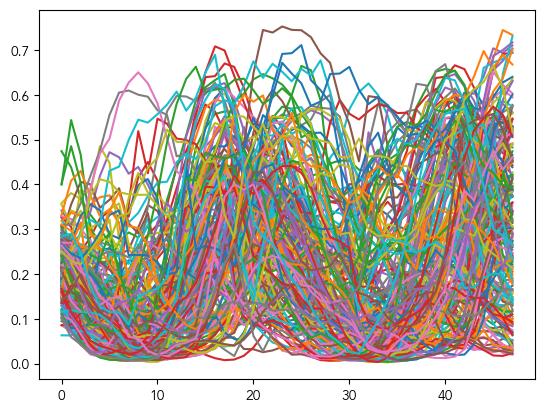

In [793]:
day = 216
interval = 6

dx_ = np.array([
    (
        t_ts + timedelta(minutes=0)
    ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
    for t_ts in t_ts_[day, interval]
])

_fdu = functional_dynamic_update(
    _distances = {'temporal': 'seasonal_equinox', 'spatial': 'graph', 'fusion': 'None'},
    name = region,
    date = dx_[24],
)
print(_fdu.name, _fdu.date)

F_tr_p_ = F_tr_[:, interval, :]
E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
print(F_tr_p_.shape, E_tr_p_.shape)

_fdu.fit(
    F_tr_p_, E_tr_p_, dt_, 
    X_ = X_tr_, 
    t_ = d_tr_, 
    n_samples_per_hour=1,
)

f_ = F_ts_[day, interval, :24]
f_hat_ = F_ts_[day, interval, 24:]
e_ = E_ts_[day, interval, ...]
e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)

M_ = _fdu.predict(
    f_, e_p_, X_ts_[day], d_ts_[day],
    clique_order = get_hyper(hyper_, "clique_order", interval),
    forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
    forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
    lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
    length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
    length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
    length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
    sigma = get_hyper(hyper_, "sigma", interval),
    nu = get_hyper(hyper_, "nu", interval),
    kappa_0 = get_hyper(hyper_, "kappa", interval),
    kappa = get_hyper(hyper_, "kappa", interval),
    p_fusion = get_hyper(hyper_, "p_fusion", interval),
)
print(np.exp(_fdu.xi), _fdu.r)
x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
print(_fdu.name, _fdu.date)
print(x_, y_)
print(np.unique(X_tr_[_fdu.idx_fed_, 1]))

file_name = f"{resource}-{region}-{day}-{interval}-zone"
print(file_name)

e_p_[:24] = np.nan
E_tr_p_[:, :24] = np.nan
print(e_p_.shape, E_tr_p_.shape)
    
plt.figure()
plt.plot(M_.T)
plt.show()

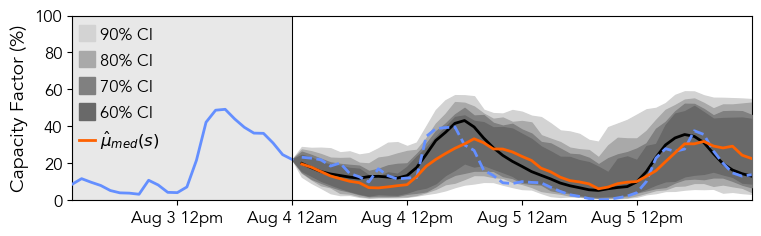

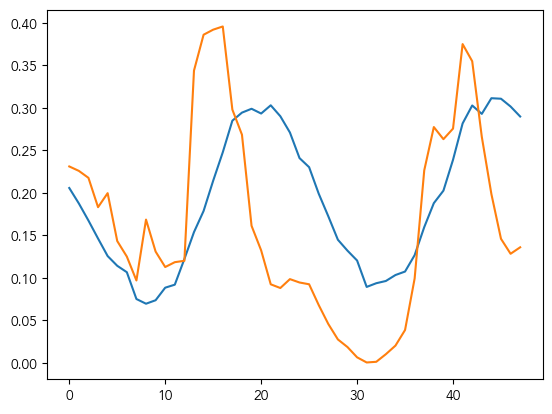

In [794]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    _fdu.M_ext_, 
    alpha_
)


f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_bands(
    _fdu.M_ext_, 
    _fdu.w_prime_,
    alpha_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _wupper, _wlower, f_wmedian_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color_med=palette_.loc[3, "ibm"],
    CR="CI",
    label=r"$\hat{\mu}_{med} (s)$",
    range_=[0, 71],
    legend_1=False,
    legend_2=True,
)

_ax.legend(
    frameon=False,
    #loc = 'upper center',
    loc=(0., 0.225),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=1,
)

plt.savefig(IMAGES / f"EDF-{file_name}.pdf")

plt.show()

plt.figure()
plt.plot(f_median_ext_[1:])
plt.plot(f_hat_)

plt.show()

(900, 48)
0 24
-0.12361111111111112 0.1162037037037027
[ 0.06759259 -0.12361111 -0.00972222  0.02546296  0.04907407  0.1162037
  0.01018519  0.01388889 -0.05787037 -0.0912037 ]


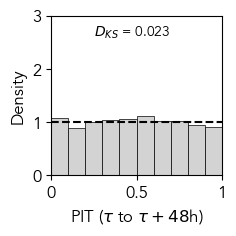

In [795]:
interval = 12
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description,
    VALIDATION,
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.25, 2.25), 
    constrained_layout = True
)

INTERVALS = [0, 6, 12, 18, 24, 30]

INTERVAL = INTERVALS[0]
LEAD = 24
bins = 10
print((INTERVAL), (INTERVAL + LEAD))
plotter.plot_pit(
    _fig, _ax, pit_[:, INTERVAL:(INTERVAL + LEAD)].flatten(), 
    v = 0.4,
    bins = bins,
    xlabel = r'PIT ($\tau$ to $\tau + 48$h)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{INTERVAL}-{LEAD}-{interval}.pdf"
)

plt.show()

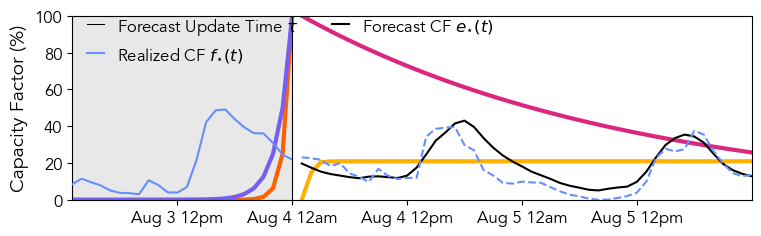

In [796]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecast_parameters(
    _fig, _ax, palette_,
    _fdu.phi_, _fdu.psi_, _fdu.eta_,
    f_, f_hat_, e_p_, dx_, dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    labels_1=True,
    labels_2=False,
)

_ax.legend(frameon=False,
           ncol=2,
           loc=(0.0125,0.7),
           #loc=(0.362,0.625),
           fontsize=12)

plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

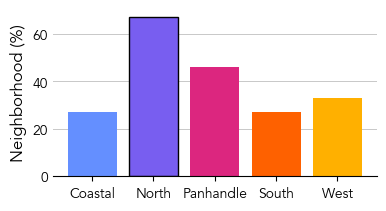

In [797]:
# Plot
_fig, _ax = plt.subplots(
    figsize=(3.75, 2), 
    constrained_layout=True
)

plotter.plot_zone_neighborhood(
    _fig, 
    _ax, 
    palette_,
    X_tr_, 
    regions_, 
    _fdu.idx_x_, 
    region,
)

plt.savefig(IMAGES / f"region_neighbors-{file_name}.pdf")

plt.show()

2025-08-03 19:00:00-05:00


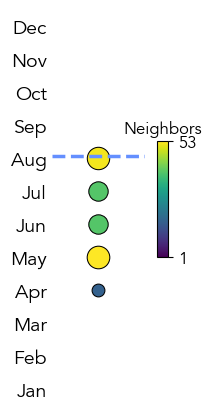

In [798]:
_fig, _ax = plt.subplots(
    figsize=(2, 4), 
    constrained_layout=True
)

print(t_ts_[day, interval, 12])
# plotter.scenarios_frequency_dates(
#     _fig, _ax, palette_,
#     _fdu.idx_neighbors_, _fdu.idx_temporal_, _fdu.idx_spatial_,
#     t_tr_[:, interval, 12],
#     t_ts_[day, interval, 12], 
#     scale=1,
#     colorbar=True,
# )
plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    t_tr_[:, interval, 12], 
    t_ts_[day, interval, 12],
    scale = 5,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neiboring_region-{file_name}.pdf")

plt.show()

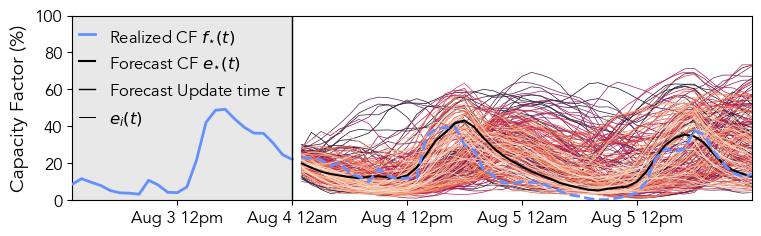

In [799]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecasts(
    _fig, _ax, palette_, 
    E_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=True,
)

_ax.legend(
    loc=(0., 0.35),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

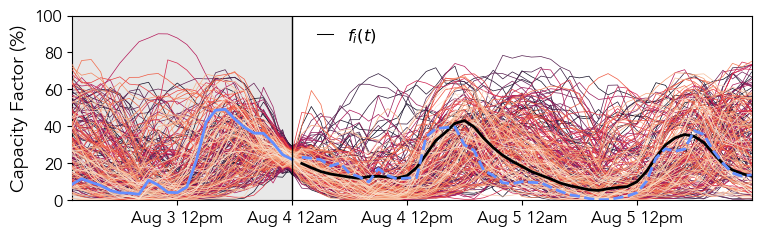

In [800]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_neighbors(
    _fig, _ax, palette_, 
    F_tr_p_, _fdu.w_fed_, _fdu.idx_x_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=False,
)

_ax.legend(
    loc=(0.35, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

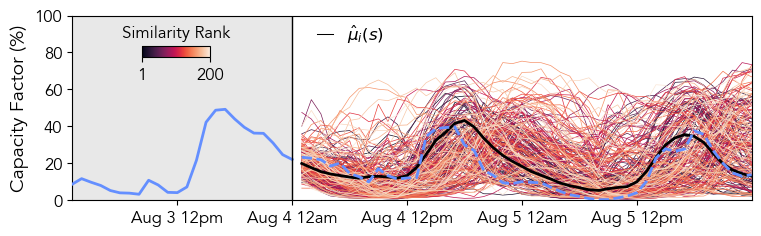

In [801]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_updates(
    _fig, _ax, palette_, M_, f_, f_hat_, e_p_, _fdu.w_fed_, _fdu.idx_x_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=True,
    legend_2=False,
    colorbar_pos = [500, 77.5, 425, 6],
)

_ax.legend(
    loc=(0.35, 0.8),
    frameon=False,
    fontsize=12,
    ncol=1
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

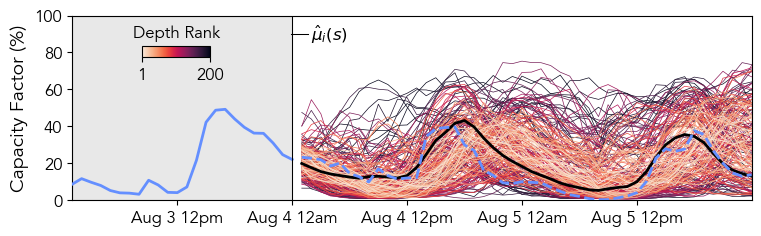

In [802]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

depth = "MBD"
depth_rank_ = _fDepth(_fdu.M_, depth, DEPTH).to_numpy()[:, 0]

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_p_, depth_rank_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    colorbar=True,
    colorbar_pos = [500, 77.5, 425, 6],
)

_ax.legend(
    frameon=False,
    loc=(0.3125, 0.8),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol=5
)

plt.savefig(IMAGES / f"ranking-{depth}_{file_name}.pdf")

plt.show()

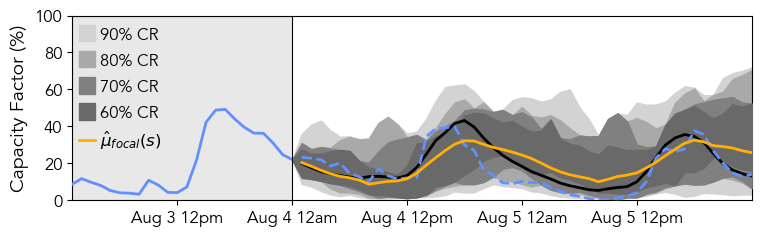

In [803]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)

J_ = _fdu.focal_curve_envelope(
    _depth, 
    _fdu.M_ext_, 
    distance
)

f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_bands(
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    color_med=palette_.loc[4, "ibm"],
    label=r"$\hat{\mu}_{focal} (s)$",
    CR="CR",
    range_=[0, 71],
    legend_1=False,
    legend_2=True,
)

_ax.legend(
    frameon=False,
    loc=(0., 0.225),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=1,
)

plt.savefig(IMAGES / f"focal_curve_envelop-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


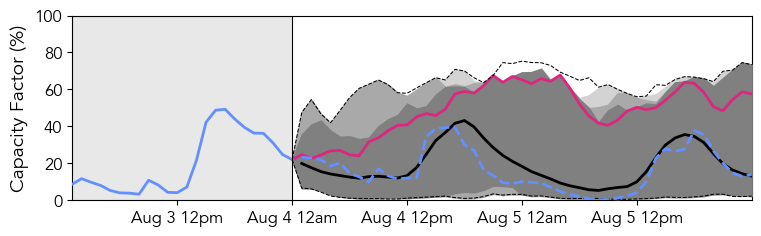

In [787]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    _fdu.M_ext_, 
    depth_rank_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_,
    dt_ = dt_ + 60, 
    interval = 24,
    n = 720,
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.1875, .825),
    fontsize = 12,
    columnspacing=0.5,
    handletextpad=0.2,
    ncol = 6
)

plt.savefig(IMAGES / f"fboxplot-{depth}_{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


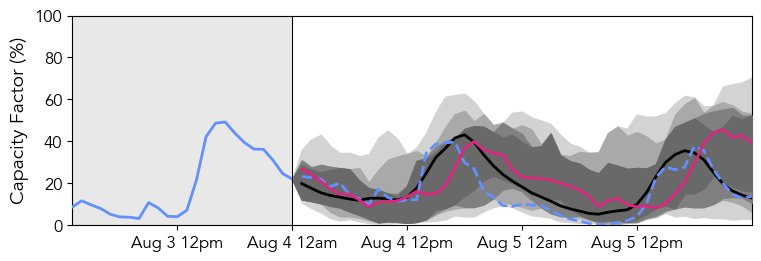

In [788]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

k_ = get_band_fraction(envelope_, alpha_, interval, distance, score)

f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
    _depth, 
    _fdu.M_ext_, 
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(
    figsize = (7.5, 2.5), 
    constrained_layout = True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval=24,
    n=720,
    color_med=palette_.loc[2, "ibm"],
    label=r"$\bar{f} (s)$",
    CR="CR",
    range_=[0, 71],
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon=False,
    loc=(0.1875, 0.825),
    fontsize=12,
    columnspacing=0.5,
    handletextpad=0.25,
    ncol=5,
)

plt.savefig(IMAGES / f"{distance}_bands-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(48,)


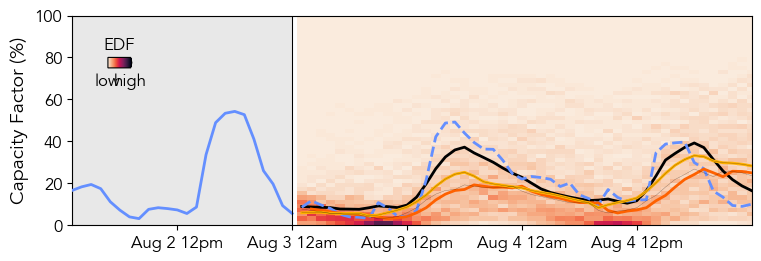

In [760]:
_fig, _ax = plt.subplots(
    figsize = (7.5, 2.5), 
    constrained_layout = True
)

plotter.plot_density_heatmap(
    _fig, _ax, palette_,
    M_, f_median_ext_, f_deepest_ext_, f_focal_ext_, f_, f_hat_, e_p_, dx_, 
    dt_ = dt_ + 60, 
    interval = 24,
    n=720,
    range_=[0, 71],
    colorbar=True,
    legend_1=False,
    legend_2=False,
)

_ax.legend(
    frameon = False,
    loc = (0.0125, .8),
    fontsize = 12,
    ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

In [21]:
print(F_ts_.shape)

(360, 24, 72)


In [789]:
day = 215
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

F_curves_ = []
E_curves_ = []
M_curves_ = []
D_curves_ = []
G_curves_ = []
dxs_ = []
dts_ = []

for i, day in enumerate([215, 216, 217]):
    for interval in range(0, 24, 1):
    
        dx_ = np.array([
            (
                t_ts + timedelta(minutes=0)
            ).strftime('%b %-d %-I%p').replace('AM', 'am').replace('PM', 'pm') 
            for t_ts in t_ts_[day, interval]
        ])

        F_tr_p_ = F_tr_[:, interval, :]
        E_tr_p_ = np.concatenate([np.zeros((E_tr_.shape[0], 24)), E_tr_[:, interval, :]], axis = 1)
        #print(F_tr_p_.shape, E_tr_p_.shape)
        
        _fdu.fit(
            F_tr_p_, E_tr_p_, dt_, 
            X_ = X_tr_, 
            t_ = d_tr_, 
            n_samples_per_hour=1,
        )
    
        f_ = F_ts_[day, interval, :24]
        f_hat_ = F_ts_[day, interval, 24:]
        e_ = E_ts_[day, interval, ...]
        e_p_ = np.concatenate([np.zeros(24,), e_, ], axis = 0)
        #print(f_.shape, f_hat_.shape, e_.shape, e_p_.shape)
        
        M_ = _fdu.predict(
            f_, e_p_, X_ts_[day], d_ts_[day],
            clique_order = get_hyper(hyper_, "clique_order", interval),
            forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
            forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
            lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
            length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
            length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
            length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
            sigma = get_hyper(hyper_, "sigma", interval),
            nu = get_hyper(hyper_, "nu", interval),
            kappa_0 = get_hyper(hyper_, "kappa", interval),
            kappa = get_hyper(hyper_, "kappa", interval),
            p_fusion = get_hyper(hyper_, "p_fusion", interval),
        )
    
        f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(_fdu.M_ext_, alpha_)
    
        k_ = get_band_fraction(
            envelope_, 
            alpha_, 
            interval, 
            "MBD", 
            "FCS",
        )
        
        f_deepest_ext_, _upper, _lower = _fdu.depth_confidence_bands(
            _depth, 
            _fdu.M_ext_, 
            alpha_, 
            k_
        )
        
        k_ = get_band_fraction(
            envelope_, 
            alpha_, 
            interval, 
            "fknn", 
            "FCS",
        )
        
        J_ = _fdu.focal_curve_envelope(
            _depth, 
            _fdu.M_ext_, 
            "fknn"
        )
        
        f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_bands(
            alpha_, 
            k_,
        )
    
        M_curves_.append(f_median_ext_)
        E_curves_.append(e_)
        D_curves_.append(f_deepest_ext_)
        F_curves_.append(f_hat_)
        G_curves_.append(f_focal_ext_)

        dts_.append(dt_ + interval*60 + i*24*60)
        dxs_.append(dx_)
        
print(len(F_curves_), len(M_curves_), len(D_curves_))

72 72 72


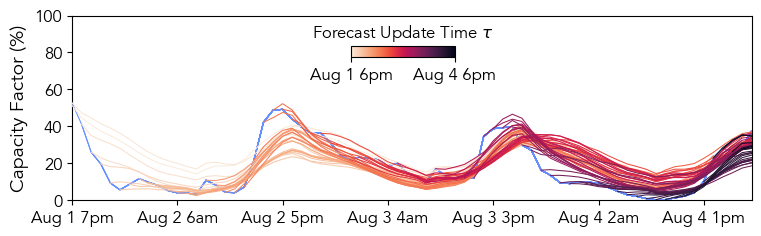

In [791]:
def plot_zonal_dynamic_update(
    _fig,
    _ax,
    palette_,
    F_curves_,
    M_curves_,
    dxs_,
    dts_,
    legend=False,
    colorbar=True,
    label=r"$\bar{f} (s)$",
    n = 120,
    range_=[],
):
    #print(np.unique(np.array(dxs_).flatten()))
    dx = np.array(dxs_).flatten()
    dt, idx_ = np.unique(np.array(dts_).flatten(), return_index=True)
    dt = dt[:-23]
    idx_ = idx_[:-23]

    dx = dx[idx_]
    
    _cmap = sns.color_palette("rocket_r", as_cmap=True)
    _norm = plt.Normalize(0.0, len(F_curves_))

    _ax.plot(
        [], [], 
        lw=0.75, 
        label=label if legend else None, 
        c="k"
    )

    for i in range(len(F_curves_)):
        _ax.plot(
            dts_[i][:-24],
            100*F_curves_[i],
            c=palette_.loc[0, "ibm"],
            lw=0.75,
            zorder=8,
        )
        
    for i in range(len(M_curves_)):
        _ax.plot(
            dts_[i][:-23] - 60,
            100*M_curves_[i],
            c=_cmap(_norm(i)),
            lw=0.75,
            zorder=8,
        )

    idx_ = (dt % n) == 0
    idx_[1] = False
    idx_[-1] = False
    _ax.set_xticks(dt[idx_], dx[idx_], rotation=0)
    
    _ax.set_ylim(0, 100)
    _ax.set_ylabel("Capacity Factor (%)", size=14)
    _ax.set_xlim(dt_[range_[0]], dt_[range_[1]])

    _ax.tick_params(axis="both", labelsize=12)

    if colorbar:
        cbar = _fig.colorbar(
            cm.ScalarMappable(_norm, _cmap),
            cax=_ax.inset_axes([1750, 77.5, 650, 6], transform=_ax.transData),
            orientation="horizontal",
        )

        cbar.set_ticks([0, len(F_curves_)], labels=["Aug 1 6pm", "Aug 4 6pm"], size=12)

        # cbar.ax.tick_params(length=0)

        cbar.ax.set_title(r"Forecast Update Time $\tau$", rotation=0, size=12)


_fig, _ax = plt.subplots(
    figsize = (7.5, 2.25), 
    constrained_layout = True
)

plot_zonal_dynamic_update(
    _fig, _ax, palette_, F_curves_, G_curves_, dxs_, dts_, 
    range_=[0, 71],
    n = 220)

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()